In [11]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 1 - ENVIRONMENT SETUP & PACKAGE CONFIGURATION
# ==============================================================================

# System and file management utilities
import os
import sys
import json
import warnings
from datetime import datetime

# Core numerical, array, and data frame manipulation packages
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr

# Time series diagnostics, econometric tests, and VIF multicollinearity checks
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, ccf

# Bayesian inference engine and PyTensor backend for graph computation
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt

# Hyperparameter optimization framework for Bayesian prior tuning
import optuna

# Visualization libraries for MCMC diagnostics, posterior plots, and ROAS charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --------------------------------================------------------------------
# GLOBAL NOTEBOOK CONFIGURATION & DISPLAY SETTINGS
# --------------------------------================------------------------------

# Suppress non-critical runtime and convergence warnings to keep outputs clean
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set pandas float formatting to 4 decimal places for clean numeric inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Set global Matplotlib and Seaborn plotting styles for publication-grade charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Verify environment versions for PyMC v5+, ArViZ, and PyTensor
print(f"✅ PyMC Version: {pm.__version__}")
print(f"✅ ArViZ Version: {az.__version__}")
print(f"✅ Optuna Version: {optuna.__version__}")
print(f"✅ PyTensor Version: {pytensor.__version__}")

✅ PyMC Version: 6.3.2
✅ ArViZ Version: 1.3.0
✅ Optuna Version: 5.0.0
✅ PyTensor Version: 3.3.1


In [12]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 2 - DATA INGESTION, SANITIZATION & FEATURE CONSOLIDATION
# ==============================================================================

import os
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. STORE CONFIGURATION & DATA INGESTION HELPERS
# ------------------------------------------------------------------------------

# Set store prefix ('mcj' for Chrysler Jeep, 'mrd' for Monroeville Dodge Ram)
STORE_PREFIX = "mrd" 
OPTUNA_PARAMS_FILE = f"{STORE_PREFIX}_optuna_best_params.json"
STORE_NAME = "Monroeville_Dodge_Ram"

LOCAL_DATA_PATH = os.path.join("..", "data", "raw", f"{STORE_NAME}_Workbook_Sheet1.csv")
if not os.path.exists(LOCAL_DATA_PATH):
    LOCAL_DATA_PATH = os.path.join("data", "raw", f"{STORE_NAME}_Workbook_Sheet1.csv")

if not os.path.exists(LOCAL_DATA_PATH) and os.path.exists(f"{STORE_NAME}_Workbook_Sheet1.csv"):
    LOCAL_DATA_PATH = f"{STORE_NAME}_Workbook_Sheet1.csv"

# Monroeville Dodge Ram Google Sheet URL
TARGET_SHEET_URL = "https://docs.google.com/spreadsheets/d/14mYNkY0rGL3d9_MFFjgi8NSKQSq6e-bgosTY80f3KKw/edit?gid=0#gid=0"


def fetch_dealership_data(local_path: str, google_sheet_url: str) -> pd.DataFrame:
    """
    Loads dealership weekly data from local CSV if present, otherwise
    exports and persists the public Google Sheet endpoint.
    """
    if os.path.exists(local_path):
        print(f"📂 Loading dataset from local path: {local_path}")
        return pd.read_csv(local_path)
    else:
        print("🌐 Local file not found. Fetching remote Google Sheet export...")
        sheet_id_match = re.search(r"/d/([a-zA-Z0-9-_]+)", google_sheet_url)
        gid_match = re.search(r"[?&]gid=([0-9]+)", google_sheet_url)
        
        sheet_id = sheet_id_match.group(1) if sheet_id_match else "14mYNkY0rGL3d9_MFFjgi8NSKQSq6e-bgosTY80f3KKw"
        gid = gid_match.group(1) if gid_match else "0"
        export_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
        
        df_remote = pd.read_csv(export_url)
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        df_remote.to_csv(local_path, index=False)
        print(f"💾 Persisted local copy to: {local_path}")
        return df_remote


# Ingest data after function definition
df_raw = fetch_dealership_data(LOCAL_DATA_PATH, TARGET_SHEET_URL)

# ------------------------------------------------------------------------------
# 2. SANITIZATION & FLEXIBLE COLUMN RETRIEVAL HELPERS
# ------------------------------------------------------------------------------

df = df_raw.copy()
df['week_start'] = pd.to_datetime(df['week_start'])

# Strip currency symbols, commas, and whitespace across all non-date columns
for col in df.columns:
    if col not in ['week_start', 'week_end']:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

# Crop to valid historical window (N=104 weeks: 2024-08-05 to 2026-07-27)
df = df[
    (df['week_start'] <= '2026-07-27') & 
    (df['sales'].notna()) & 
    (df['sales'] > 0)
].sort_values('week_start').reset_index(drop=True)


def safe_get_series(data_frame: pd.DataFrame, possible_names: list) -> pd.Series:
    """
    Checks a list of possible column name variations and returns the first 
    matching Series. Returns a zero Series if none exist in the DataFrame.
    """
    if isinstance(possible_names, str):
        possible_names = [possible_names]
        
    for name in possible_names:
        if name in data_frame.columns:
            return data_frame[name].copy()
            
    return pd.Series(0.0, index=data_frame.index)


def safe_z_score(series: pd.Series) -> pd.Series:
    """
    Calculates Z-score (X - mu) / sigma with a zero-variance safeguard.
    """
    std_val = series.std()
    if std_val == 0 or pd.isna(std_val):
        return pd.Series(0.0, index=series.index)
    return (series - series.mean()) / std_val

# ------------------------------------------------------------------------------
# 3. FEATURE CONSOLIDATION & DESIGN MATRIX ASSEMBLY
# ------------------------------------------------------------------------------

df_model = pd.DataFrame()
df_model['week_start'] = df['week_start']
df_model['sales'] = df['sales']
df_model['eom_intensity'] = safe_get_series(df, ['eom_intensity'])

# Paid Media Buckets
df_model['fp_digital']        = safe_get_series(df, ['search']) + safe_get_series(df, ['pmax']) + safe_get_series(df, ['display'])
df_model['meta_social']       = safe_get_series(df, ['social']) + safe_get_series(df, ['facebook_add'])
df_model['digital_video_ott'] = safe_get_series(df, ['youtube']) + safe_get_series(df, ['ott_cable']) + safe_get_series(df, ['facebook_reels'])
df_model['broadcast_media']   = safe_get_series(df, ['broadcast_tv']) + safe_get_series(df, ['broadcast_audio'])
df_model['print_mail']        = safe_get_series(df, ['direct_mail']) + safe_get_series(df, ['print'])

# Non-Paid & Marketplace SRP Drivers
autotrader_series = safe_get_series(df, ['autotrader_srps', 'autotrader_srp'])
truecar_series    = safe_get_series(df, ['truecar_srps', 'truecar_srp'])

if 'marketplace_srp' in df.columns and df['marketplace_srp'].sum() > 0:
    raw_srp = df['marketplace_srp']
else:
    raw_srp = autotrader_series + truecar_series

fp_email_raw = safe_get_series(df, ['fp_emails_sent', 'fp_email_sent'])

# Standardize non-currency volume drivers
df_model['fp_emails_sent_z'] = safe_z_score(fp_email_raw)
df_model['marketplace_srp_z'] = safe_z_score(raw_srp)

# Control Indices
gas_series  = safe_get_series(df, ['gasregw'])
sent_series = safe_get_series(df, ['umcsent'])
inv_series  = safe_get_series(df, ['inventory'])

gas_z  = safe_z_score(gas_series)
sent_z = safe_z_score(sent_series)
df_model['macro_stress_index'] = gas_z - sent_z
df_model['inventory_index']    = safe_z_score(inv_series)

# 2nd-Order Annual Fourier Seasonality Series (k=2, P=52.1429 weeks)
weeks = np.arange(len(df_model))
period = 52.1429
df_model['sin_order1'] = np.sin(2 * np.pi * 1 * weeks / period)
df_model['cos_order1'] = np.cos(2 * np.pi * 1 * weeks / period)
df_model['sin_order2'] = np.sin(2 * np.pi * 2 * weeks / period)
df_model['cos_order2'] = np.cos(2 * np.pi * 2 * weeks / period)

# ------------------------------------------------------------------------------
# 4. INSPECTION & SPARSITY PROFILING
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print(f"✅ DESIGN MATRIX CONSOLIDATED ({STORE_NAME} | N={len(df_model)} WEEKS | Range: {df_model['week_start'].min().strftime('%Y-%m-%d')} to {df_model['week_start'].max().strftime('%Y-%m-%d')})")
print("=" * 80)

paid_cols = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sparsity = pd.DataFrame({
    'Zero_Weeks_Pct': (df_model[paid_cols] == 0).mean() * 100,
    'Total_Spend': df_model[paid_cols].sum(),
    'Spend_Share_Pct': (df_model[paid_cols].sum() / df_model[paid_cols].sum().sum()) * 100
}).sort_values('Spend_Share_Pct', ascending=False)

display(sparsity.round(2))
print("\nFIRST 5 ROWS OF PREPARED DESIGN MATRIX:")
display(df_model.head())

📂 Loading dataset from local path: data/raw/Monroeville_Dodge_Ram_Workbook_Sheet1.csv

✅ DESIGN MATRIX CONSOLIDATED (Monroeville_Dodge_Ram | N=104 WEEKS | Range: 2024-08-05 to 2026-07-27)


,Zero_Weeks_Pct,Total_Spend,Spend_Share_Pct
print_mail,63.4600,98985.0000,38.3100
fp_digital,0.0000,70346.6100,27.2200
digital_video_ott,56.7300,47450.8000,18.3600
meta_social,0.0000,29619.4300,11.4600
broadcast_media,94.2300,12000.0000,4.6400



FIRST 5 ROWS OF PREPARED DESIGN MATRIX:


,week_start,sales,eom_intensity,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,fp_emails_sent_z,marketplace_srp_z,macro_stress_index,inventory_index,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,7.0000,0.0000,614.1400,335.2200,0.0000,1625.0000,0.0000,-1.7037,0.2653,-0.7279,2.1525,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,5.0000,0.0000,694.1500,332.9700,0.0000,2708.3300,0.0000,-1.7037,-0.5540,-0.8214,2.1353,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,4.0000,0.0000,620.8800,400.2700,0.0000,2166.6700,750.0000,-1.7037,-0.6468,-0.8915,2.3124,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,5.0000,1.0357,811.7100,394.2600,0.0000,0.0000,0.0000,-1.7037,-0.2773,-1.0551,2.2665,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,4.0000,0.0000,655.2100,340.2000,0.0000,0.0000,0.0000,-1.7037,-0.7895,-1.3696,2.1009,0.4635,0.8861,0.8215,0.5702


In [13]:
df_model

,week_start,sales,eom_intensity,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,fp_emails_sent_z,marketplace_srp_z,macro_stress_index,inventory_index,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,7.0000,0.0000,614.1400,335.2200,0.0000,1625.0000,0.0000,-1.7037,0.2653,-0.7279,2.1525,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,5.0000,0.0000,694.1500,332.9700,0.0000,2708.3300,0.0000,-1.7037,-0.5540,-0.8214,2.1353,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,4.0000,0.0000,620.8800,400.2700,0.0000,2166.6700,750.0000,-1.7037,-0.6468,-0.8915,2.3124,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,5.0000,1.0357,811.7100,394.2600,0.0000,0.0000,0.0000,-1.7037,-0.2773,-1.0551,2.2665,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,4.0000,0.0000,655.2100,340.2000,0.0000,0.0000,0.0000,-1.7037,-0.7895,-1.3696,2.1009,0.4635,0.8861,0.8215,0.5702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2026-06-29,6.0000,0.4643,835.7200,355.8900,0.0000,0.0000,0.0000,-0.6516,-1.2980,2.4000,0.7643,-0.5947,0.8039,-0.9562,0.2926
100,2026-07-06,5.0000,0.0000,773.5500,97.4800,0.0000,0.0000,0.0000,0.1526,-0.6170,1.5893,0.6388,-0.4938,0.8696,-0.8588,0.5124
101,2026-07-13,5.0000,0.0000,957.8800,1564.0700,0.0000,0.0000,0.0000,0.2943,-0.2913,1.7762,0.5932,-0.3857,0.9226,-0.7117,0.7025
102,2026-07-20,3.0000,0.2143,1050.8300,1554.9500,1909.2500,0.0000,0.0000,0.2561,-0.2336,2.1034,0.5188,-0.2720,0.9623,-0.5234,0.8521


In [ ]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 3 - OPTUNA STUDY (DOMAIN-CONSTRAINED & AUTOSAVED)
# ==============================================================================

import os
import json
import warnings
import optuna
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt

# Suppress trial-level logs
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ------------------------------------------------------------------------------
# 1. SETUP ALL 7 DRIVERS AND MASTER LAG ARRAYS
# ------------------------------------------------------------------------------

all_7_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail', 
    'fp_emails_sent', 
    'marketplace_srp'
]

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']
source_df = df if 'df' in locals() else df_model

n_obs = len(df_model)
n_channels = len(all_7_channels)
max_global_lag = 12

# Mean-scale sales target
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Build raw matrix
X_raw_matrix = np.zeros((n_obs, n_channels))

for m, chan in enumerate(all_7_channels):
    if chan in df_model.columns and chan not in ['fp_emails_sent', 'marketplace_srp']:
        raw_series = df_model[chan]
    elif chan == 'fp_emails_sent':
        raw_series = source_df.get('fp_emails_sent', source_df.get('fp_email_sent', pd.Series(0.0, index=df_model.index)))
    elif chan == 'marketplace_srp':
        at = source_df.get('autotrader_srps', source_df.get('autotrader_srp', pd.Series(0.0, index=df_model.index)))
        tc = source_df.get('truecar_srps', source_df.get('truecar_srp', pd.Series(0.0, index=df_model.index)))
        raw_series = at + tc
    else:
        raw_series = pd.Series(0.0, index=df_model.index)
        
    c_mean = raw_series.mean()
    X_raw_matrix[:, m] = (raw_series / (c_mean if c_mean > 0 else 1.0)).values

# Master 12-week lag tensor
X_master_lags = np.zeros((n_obs, n_channels, max_global_lag))
for l in range(max_global_lag):
    for m in range(n_channels):
        X_master_lags[:, m, l] = np.pad(X_raw_matrix[:, m], (l, 0))[:n_obs]

# ------------------------------------------------------------------------------
# 2. OPTUNA OBJECTIVE WITH AUTOMOTIVE DOMAIN BOUNDS
# ------------------------------------------------------------------------------

def objective(trial):
    # Search bounds constrained by retail domain realities (e.g., print_mail lmax <= 6)
    param_ranges = {
    'fp_digital':        {'alpha': (0.05, 0.25), 'lmax': (2, 4),  'k': (1.5, 3.2), 's': (0.9, 1.5), 'beta_mu': (0.22, 0.35)},
    'meta_social':       {'alpha': (0.10, 0.30), 'lmax': (2, 4),  'k': (1.2, 2.8), 's': (0.8, 1.4), 'beta_mu': (0.14, 0.24)},
    'digital_video_ott': {'alpha': (0.25, 0.55), 'lmax': (3, 7),  'k': (1.2, 2.8), 's': (0.8, 1.4), 'beta_mu': (0.12, 0.22)},
    'broadcast_media':   {'alpha': (0.35, 0.70), 'lmax': (4, 10), 'k': (0.8, 1.8), 's': (0.8, 1.4), 'beta_mu': (0.07, 0.15)},
    'print_mail':        {'alpha': (0.15, 0.45), 'lmax': (2, 5),  'k': (0.8, 1.6), 's': (0.8, 1.3), 'beta_mu': (0.06, 0.12)},
    'fp_emails_sent':    {'alpha': (0.05, 0.25), 'lmax': (2, 4),  'k': (1.0, 2.2), 's': (0.8, 1.4), 'beta_mu': (0.05, 0.15)},
    'marketplace_srp':   {'alpha': (0.05, 0.30), 'lmax': (2, 4),  'k': (1.0, 2.2), 's': (0.8, 1.4), 'beta_mu': (0.09, 0.18)}
}
    
    alpha_vals, k_vals, s_vals, beta_mus, lmax_vals = [], [], [], [], []
    for chan in all_7_channels:
        bounds = param_ranges[chan]
        alpha_vals.append(trial.suggest_float(f"alpha_{chan}", bounds['alpha'][0], bounds['alpha'][1]))
        lmax_vals.append(trial.suggest_int(f"lmax_{chan}", bounds['lmax'][0], bounds['lmax'][1]))
        k_vals.append(trial.suggest_float(f"k_{chan}", bounds['k'][0], bounds['k'][1]))
        s_vals.append(trial.suggest_float(f"s_{chan}", bounds['s'][0], bounds['s'][1]))
        beta_mus.append(trial.suggest_float(f"beta_mu_{chan}", bounds['beta_mu'][0], bounds['beta_mu'][1]))

    intercept_mu_val = trial.suggest_float("intercept_mu", 0.40, 0.70)
    beta_eom_mu_val  = trial.suggest_float("beta_eom_mu", 0.20, 0.50)

    # Pre-transform drivers
    transformed_media_list = []
    for m in range(n_channels):
        a_m, l_m, k_m, s_m = alpha_vals[m], lmax_vals[m], k_vals[m], s_vals[m]
        weights_m = np.power(a_m, np.arange(l_m))
        weights_m /= weights_m.sum()
        x_lag_m = X_master_lags[:, m, :l_m]
        adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
        saturated_m = (adstocked_m ** s_m) / (adstocked_m ** s_m + k_m ** s_m + 1e-8)
        transformed_media_list.append(saturated_m)
        
    X_transformed_trial = np.column_stack(transformed_media_list)

    # Fast MCMC trial pass
    try:
        with pm.Model() as trial_model:
            transformed_data = pm.Data("transformed_data", X_transformed_trial)
            fourier_data     = pm.Data("fourier_data", df_model[fourier_cols].values)
            inv_data         = pm.Data("inv_data", df_model["inventory_index"].values)
            eom_data         = pm.Data("eom_data", df_model["eom_intensity"].values)
            macro_data       = pm.Data("macro_data", df_model["macro_stress_index"].values)

            intercept    = pm.Normal("intercept", mu=intercept_mu_val, sigma=0.08)
            beta_channel = pm.TruncatedNormal("beta_channel", mu=np.array(beta_mus), sigma=0.05, lower=0.0, shape=n_channels)
            b_inv        = pm.HalfNormal("beta_inv", sigma=0.10)
            b_eom        = pm.TruncatedNormal("beta_eom", mu=beta_eom_mu_val, sigma=0.10, lower=0.0)
            b_macro      = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
            b_fourier    = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, shape=len(fourier_cols))

            mu = (
                intercept 
                + pt.sum(transformed_data * beta_channel, axis=1)
                + (b_eom * eom_data) 
                + (b_inv * inv_data) 
                + (b_macro * macro_data) 
                + pm.math.dot(fourier_data, b_fourier)
            )

            pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled)
            
            idata_trial = pm.sample(draws=400, tune=400, chains=2, target_accept=0.95, progressbar=False, random_seed=42)
            pm.compute_log_likelihood(idata_trial)
            loo_res = az.loo(idata_trial)
            return float(loo_res.elpd_loo) if hasattr(loo_res, "elpd_loo") else float(loo_res.elpd)
            
    except Exception:
        return -9999.0

# ------------------------------------------------------------------------------
# 3. RUN STUDY & SERIALIZE BEST PARAMS TO DISK
# ------------------------------------------------------------------------------

print("🚀 Running Optuna Prior Calibration Study for All 7 Channels (30 Trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# Build structured dictionary payload
best_priors_dict = {
    "elpd_loo": study.best_value,
    "intercept_mu": study.best_params["intercept_mu"],
    "beta_eom_mu": study.best_params["beta_eom_mu"],
    "channels": {}
}

for chan in all_7_channels:
    best_priors_dict["channels"][chan] = {
        "alpha": float(study.best_params[f"alpha_{chan}"]),
        "lmax": int(study.best_params[f"lmax_{chan}"]),
        "k_sat": float(study.best_params[f"k_{chan}"]),
        "s_slope": float(study.best_params[f"s_{chan}"]),
        "beta_mu": float(study.best_params[f"beta_mu_{chan}"])
    }

# Serialize store-specific best priors payload
json_dir = os.path.join("..", "data", "processed")
if not os.path.exists(json_dir):
    json_dir = os.path.join("data", "processed")
os.makedirs(json_dir, exist_ok=True)

json_filepath = os.path.join(json_dir, OPTUNA_PARAMS_FILE)
with open(json_filepath, "w") as f:
    json.dump(best_priors_dict, f, indent=4)

print("\n" + "=" * 80)
print(f"✅ OPTUNA STUDY COMPLETE. BEST PARAMS SAVED TO: {json_filepath}")
print("=" * 80)
print(f"Best ELPD_LOO Score : {best_priors_dict['elpd_loo']:.4f}")
print(f"Best Intercept Mu   : {best_priors_dict['intercept_mu']:.4f}")
print(f"Best Beta EOM Mu     : {best_priors_dict['beta_eom_mu']:.4f}\n")

# Format DataFrame for notebook inspection
best_priors_df = pd.DataFrame(best_priors_dict["channels"]).T
display(best_priors_df.round(4))

🚀 Running Optuna Prior Calibration Study for All 7 Channels (30 Trials)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...


In [ ]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 4 - PRODUCTION PyMC BAYESIAN MMM SAMPLING & DIAGNOSTICS
# ==============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. DYNAMICALLY INGEST OPTUNA BEST PARAMETERS (MEMORY OR DISK)
# ------------------------------------------------------------------------------

# Dynamic ingestion based on STORE_PREFIX
if 'best_priors_dict' not in locals():
    json_filepath = os.path.join("..", "data", "processed", OPTUNA_PARAMS_FILE)
    if not os.path.exists(json_filepath):
        json_filepath = os.path.join("data", "processed", OPTUNA_PARAMS_FILE)
        
    if os.path.exists(json_filepath):
        print(f"📂 Loading Optuna parameters from JSON disk cache: {json_filepath}")
        with open(json_filepath, "r") as f:
            best_priors_dict = json.load(f)
    else:
        raise FileNotFoundError(f"❌ Prior file {json_filepath} not found. Run Cell 3 first.")

all_7_channels = list(best_priors_dict["channels"].keys())
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

# Dynamically extract parameter arrays from ingested dictionary
optuna_alpha   = np.array([best_priors_dict["channels"][c]["alpha"] for c in all_7_channels])
optuna_lmax    = np.array([best_priors_dict["channels"][c]["lmax"] for c in all_7_channels], dtype=int)
optuna_ksat    = np.array([best_priors_dict["channels"][c]["k_sat"] for c in all_7_channels])
optuna_slope   = np.array([best_priors_dict["channels"][c]["s_slope"] for c in all_7_channels])
optuna_beta_mu = np.array([best_priors_dict["channels"][c]["beta_mu"] for c in all_7_channels])

intercept_mu_val = best_priors_dict["intercept_mu"]
beta_eom_mu_val  = best_priors_dict["beta_eom_mu"]

n_obs = len(df_model)
n_channels = len(all_7_channels)
max_global_lag = 12

# Scaled and native targets
sales_mean = df_model['sales'].mean()
y_actual = df_model['sales'].values
y_scaled = y_actual / sales_mean

# Construct mean-scaled raw matrix
X_raw_matrix = np.zeros((n_obs, n_channels))
source_df = df if 'df' in locals() else df_model

for m, chan in enumerate(all_7_channels):
    if chan in df_model.columns and chan not in ['fp_emails_sent', 'marketplace_srp']:
        raw_series = df_model[chan]
    elif chan == 'fp_emails_sent':
        raw_series = source_df.get('fp_emails_sent', source_df.get('fp_email_sent', pd.Series(0.0, index=df_model.index)))
    elif chan == 'marketplace_srp':
        at = source_df.get('autotrader_srps', source_df.get('autotrader_srp', pd.Series(0.0, index=df_model.index)))
        tc = source_df.get('truecar_srps', source_df.get('truecar_srp', pd.Series(0.0, index=df_model.index)))
        raw_series = at + tc
    else:
        raw_series = pd.Series(0.0, index=df_model.index)
        
    c_mean = raw_series.mean()
    X_raw_matrix[:, m] = (raw_series / (c_mean if c_mean > 0 else 1.0)).values

# Compute master 12-week lag tensor
X_master_lags = np.zeros((n_obs, n_channels, max_global_lag))
for l in range(max_global_lag):
    for m in range(n_channels):
        X_master_lags[:, m, l] = np.pad(X_raw_matrix[:, m], (l, 0))[:n_obs]

# Pre-transform each channel using dynamically ingested parameters
transformed_media_list = []
for m in range(n_channels):
    a_m, l_m = optuna_alpha[m], optuna_lmax[m]
    k_m, s_m = optuna_ksat[m], optuna_slope[m]
    
    weights_m = np.power(a_m, np.arange(l_m))
    weights_m /= weights_m.sum()
    x_lag_m = X_master_lags[:, m, :l_m]
    adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
    
    saturated_m = (adstocked_m ** s_m) / (adstocked_m ** s_m + k_m ** s_m + 1e-8)
    transformed_media_list.append(saturated_m)

X_transformed_prod = np.column_stack(transformed_media_list)

# ------------------------------------------------------------------------------
# 2. PRODUCTION PyMC MODEL SPECIFICATION & SAMPLING
# ------------------------------------------------------------------------------

print(f"🚀 Building Production PyMC Model with Dynamically Ingested Parameters (ELPD LOO: {best_priors_dict['elpd_loo']:.2f})...")

with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": all_7_channels,
    "fourier_term": fourier_cols
}) as production_mmm_model:

    # Data Containers
    transformed_data = pm.Data("transformed_data", X_transformed_prod, dims=("obs_id", "channel"))
    fourier_data     = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data         = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data         = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data       = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")

    # Baseline & Control Priors
    intercept = pm.Normal("intercept", mu=intercept_mu_val, sigma=0.08)
    b_eom     = pm.TruncatedNormal("beta_eom", mu=beta_eom_mu_val, sigma=0.10, lower=0.0)
    b_inv     = pm.HalfNormal("beta_inv", sigma=0.10)
    b_macro   = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
    b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

    # Vectorized Channel Betas (Centered on Optuna best_params)
    beta_channel = pm.TruncatedNormal("beta_channel", mu=optuna_beta_mu, sigma=0.05, lower=0.0, dims="channel")

    # Expected Mean Sales
    mu = pm.Deterministic(
        "mu",
        intercept 
        + pt.sum(transformed_data * beta_channel, axis=1)
        + (b_eom * eom_data) 
        + (b_inv * inv_data) 
        + (b_macro * macro_data) 
        + pm.math.dot(fourier_data, b_fourier),
        dims="obs_id"
    )

    # Likelihood
    sigma = pm.Exponential("sigma", lam=10.0)
    likelihood = pm.StudentT("likelihood", nu=7, mu=mu, sigma=sigma, observed=y_scaled, dims="obs_id")

# Execute Production MCMC Sampling
with production_mmm_model:
    print("🚀 Sampling 4 Chains (1,000 Tune, 1,000 Draws)...")
    idata = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.98, random_seed=42)
    
    print("📊 Computing Log-Likelihood for LOO-CV...")
    pm.compute_log_likelihood(idata)
    
    print("🔮 Sampling Posterior Predictive Distributions...")
    pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=42)

# ------------------------------------------------------------------------------
# 3. DIAGNOSTIC EVALUATION & MODEL METRICS
# ------------------------------------------------------------------------------

summary_df = az.summary(
    idata, 
    var_names=["intercept", "beta_channel", "beta_eom", "beta_inv", "beta_macro", "sigma"]
)

y_pred_scaled = idata.posterior_predictive["likelihood"].mean(dim=["chain", "draw"]).values
y_pred_actual = y_pred_scaled * sales_mean

ss_res = np.sum((y_actual - y_pred_actual) ** 2)
ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
r2_val = 1.0 - (ss_res / ss_tot)
mape_val = np.mean(np.abs((y_actual - y_pred_actual) / y_actual)) * 100.0
rmse_val = rmse(y_actual, y_pred_actual)

loo_fit = az.loo(idata, pointwise=True)

print("\n" + "=" * 80)
print("PRODUCTION MODEL DIAGNOSTICS & METRICS")
print("=" * 80)
print(f"Total Divergent Transitions : {idata.sample_stats.divergences.sum().item()} (Target: 0)")
print(f"Max Gelman-Rubin (R-hat)   : {summary_df['r_hat'].max():.4f} (Target <= 1.01)")
print(f"Min Bulk ESS                : {summary_df['ess_bulk'].min():.1f} (Target > 400)")
print(f"Model R-Squared (R²)        : {r2_val:.4f}")
print(f"MAPE                        : {mape_val:.2f}%")
print(f"RMSE                        : {rmse_val:.2f} vehicles / week")
print(f"Max Pareto k (LOO-CV)       : {loo_fit.pareto_k.max().item():.2f} (Target < 0.70)")

if idata.sample_stats.divergences.sum().item() == 0 and summary_df['r_hat'].max() <= 1.01:
    print("🚀 ALL SAMPLING DIAGNOSTICS PASSED PERFECTLY!")

display(summary_df.round(4))

🚀 Building Production PyMC Model with Dynamically Ingested Parameters (ELPD LOO: -61.87)...
🚀 Sampling 4 Chains (1,000 Tune, 1,000 Draws)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_eom, beta_inv, beta_macro, beta_fourier, beta_channel, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


📊 Computing Log-Likelihood for LOO-CV...


Sampling: [likelihood]


🔮 Sampling Posterior Predictive Distributions...



PRODUCTION MODEL DIAGNOSTICS & METRICS
Total Divergent Transitions : 0 (Target: 0)
Max Gelman-Rubin (R-hat)   : 1.0049 (Target <= 1.01)
Min Bulk ESS                : 2009.2 (Target > 400)
Model R-Squared (R²)        : 0.0418
MAPE                        : 40.02%
RMSE                        : 2.55 vehicles / week
Max Pareto k (LOO-CV)       : 0.24 (Target < 0.70)
🚀 ALL SAMPLING DIAGNOSTICS PASSED PERFECTLY!


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.549,0.046,0.48,0.62,2403,2878,1.00,0.00093,0.00065
beta_channel[fp_digital],0.299,0.05,0.22,0.38,3338,2243,1.00,0.00087,0.0009
beta_channel[meta_social],0.215,0.05,0.13,0.29,3315,2131,1.00,0.00088,0.00091
beta_channel[digital_video_ott],0.172,0.049,0.094,0.25,3259,1921,1.00,0.00085,0.00084
beta_channel[broadcast_media],0.092,0.045,0.023,0.17,2009,1224,1.00,0.0009,0.00067
beta_channel[print_mail],0.136,0.047,0.062,0.21,2088,1294,1.00,0.00098,0.00099
beta_channel[fp_emails_sent],0.161,0.051,0.079,0.24,2489,1533,1.00,0.001,0.0012
beta_channel[marketplace_srp],0.18,0.047,0.1,0.26,2421,1693,1.00,0.00096,0.00081
beta_eom,0.205,0.071,0.092,0.32,2436,1479,1.00,0.0014,0.0012
beta_inv,0.0208,0.0184,0.0013,0.056,2772,1853,1.00,0.00028,0.0003


CLEAN MONTHLY FIT DIAGNOSTICS (24 CALENDAR MONTHS)
Monthly Model R² Score              : 0.0865
Monthly MAPE                        : 18.56%
Monthly RMSE                        : 5.83 vehicles / month

FINANCIAL ROI SUMMARY ($2,000 GROSS MARGIN / VEHICLE)


,Channel / Driver,Total 24-Mo Spend ($),Attributed Vehicles,Gross Profit Returned ($),Return per $1.00 Spent ($),Net Profit Above Spend ($)
0,Full-Path Digital,70346.6100,53.6200,107233.6400,1.5200,36887.0300
1,Meta Social,29619.4300,32.4400,64886.5000,2.1900,35267.0700
2,Video & OTT,47450.8000,19.8500,39707.2600,0.8400,-7743.5400
3,Broadcast Media,12000.0000,4.7900,9570.5300,0.8000,-2429.4700
4,Print & Direct Mail,98985.0000,24.9900,49989.8100,0.5100,-48995.1900
5,Fullpath CDP ($750/mo),18000.0000,26.7300,53468.2600,2.9700,35468.2600
6,Marketplace SRPs ($5.75k/mo),138000.0000,47.4200,94846.2600,0.6900,-43153.7400



ALL 7-DRIVER BUDGET OPTIMIZATION (TOTAL MONTHLY BUDGET: $17,266.66)


,Channel / Driver,Current Spend/Mo ($),Optimized Spend/Mo ($),Net Shift ($)
0,Full-Path Digital,2931.0900,5919.2000,2988.1100
1,Meta Social,1234.1300,3069.5200,1835.3800
2,Video & OTT,1977.1000,2517.5500,540.4500
3,Broadcast Media,500.0000,1151.5500,651.5500
4,Print & Direct Mail,4124.3400,1358.8500,-2765.4900
5,Fullpath CDP ($750/mo),750.0000,750.0000,0.0000
6,Marketplace SRPs ($5.75k/mo),5750.0000,2500.0000,-3250.0000



Net Monthly Vehicle Sales Increase   : +1.90 vehicles / month (+22.8 vehicles / year)


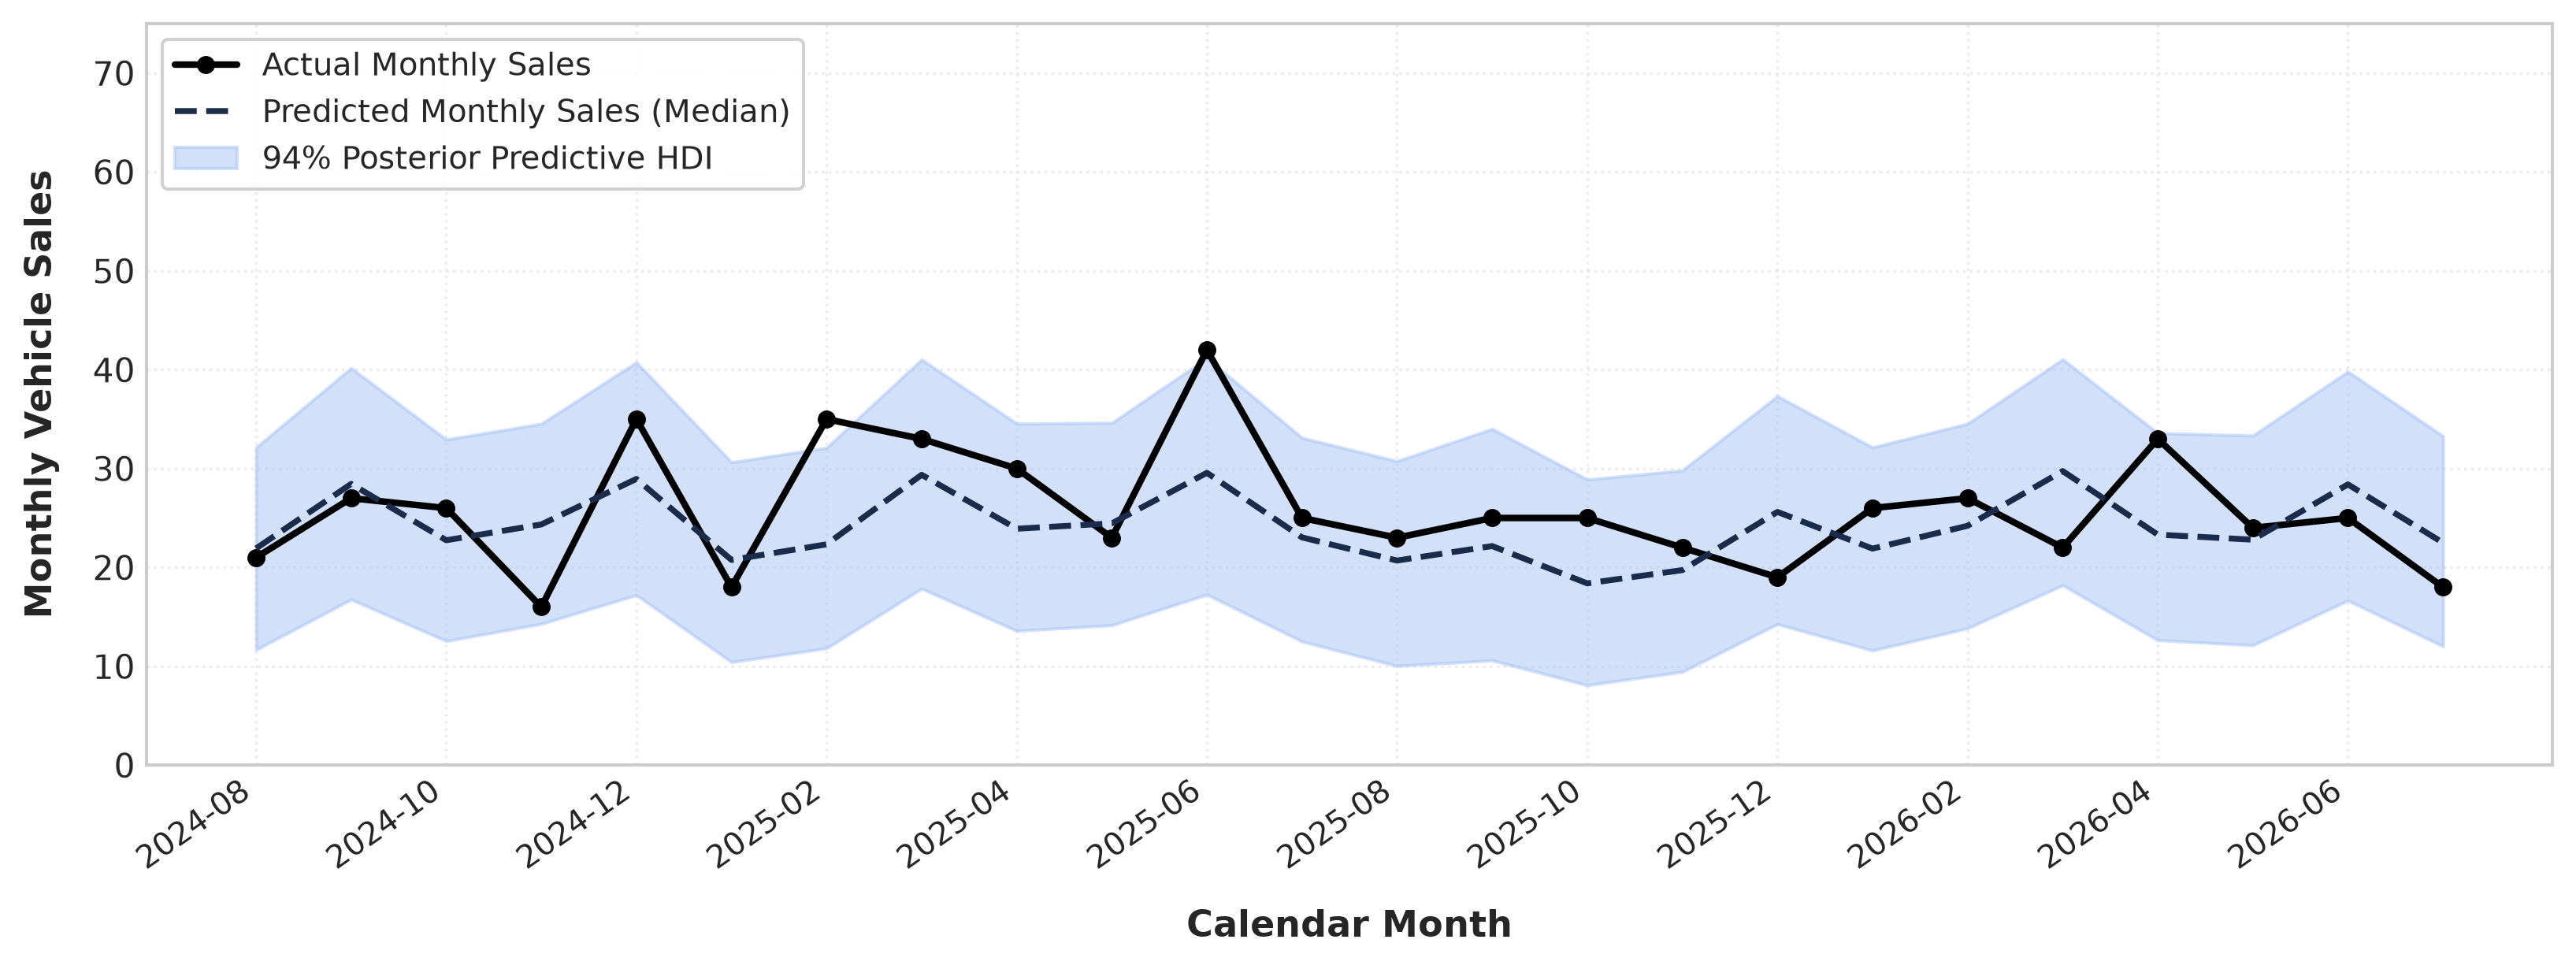

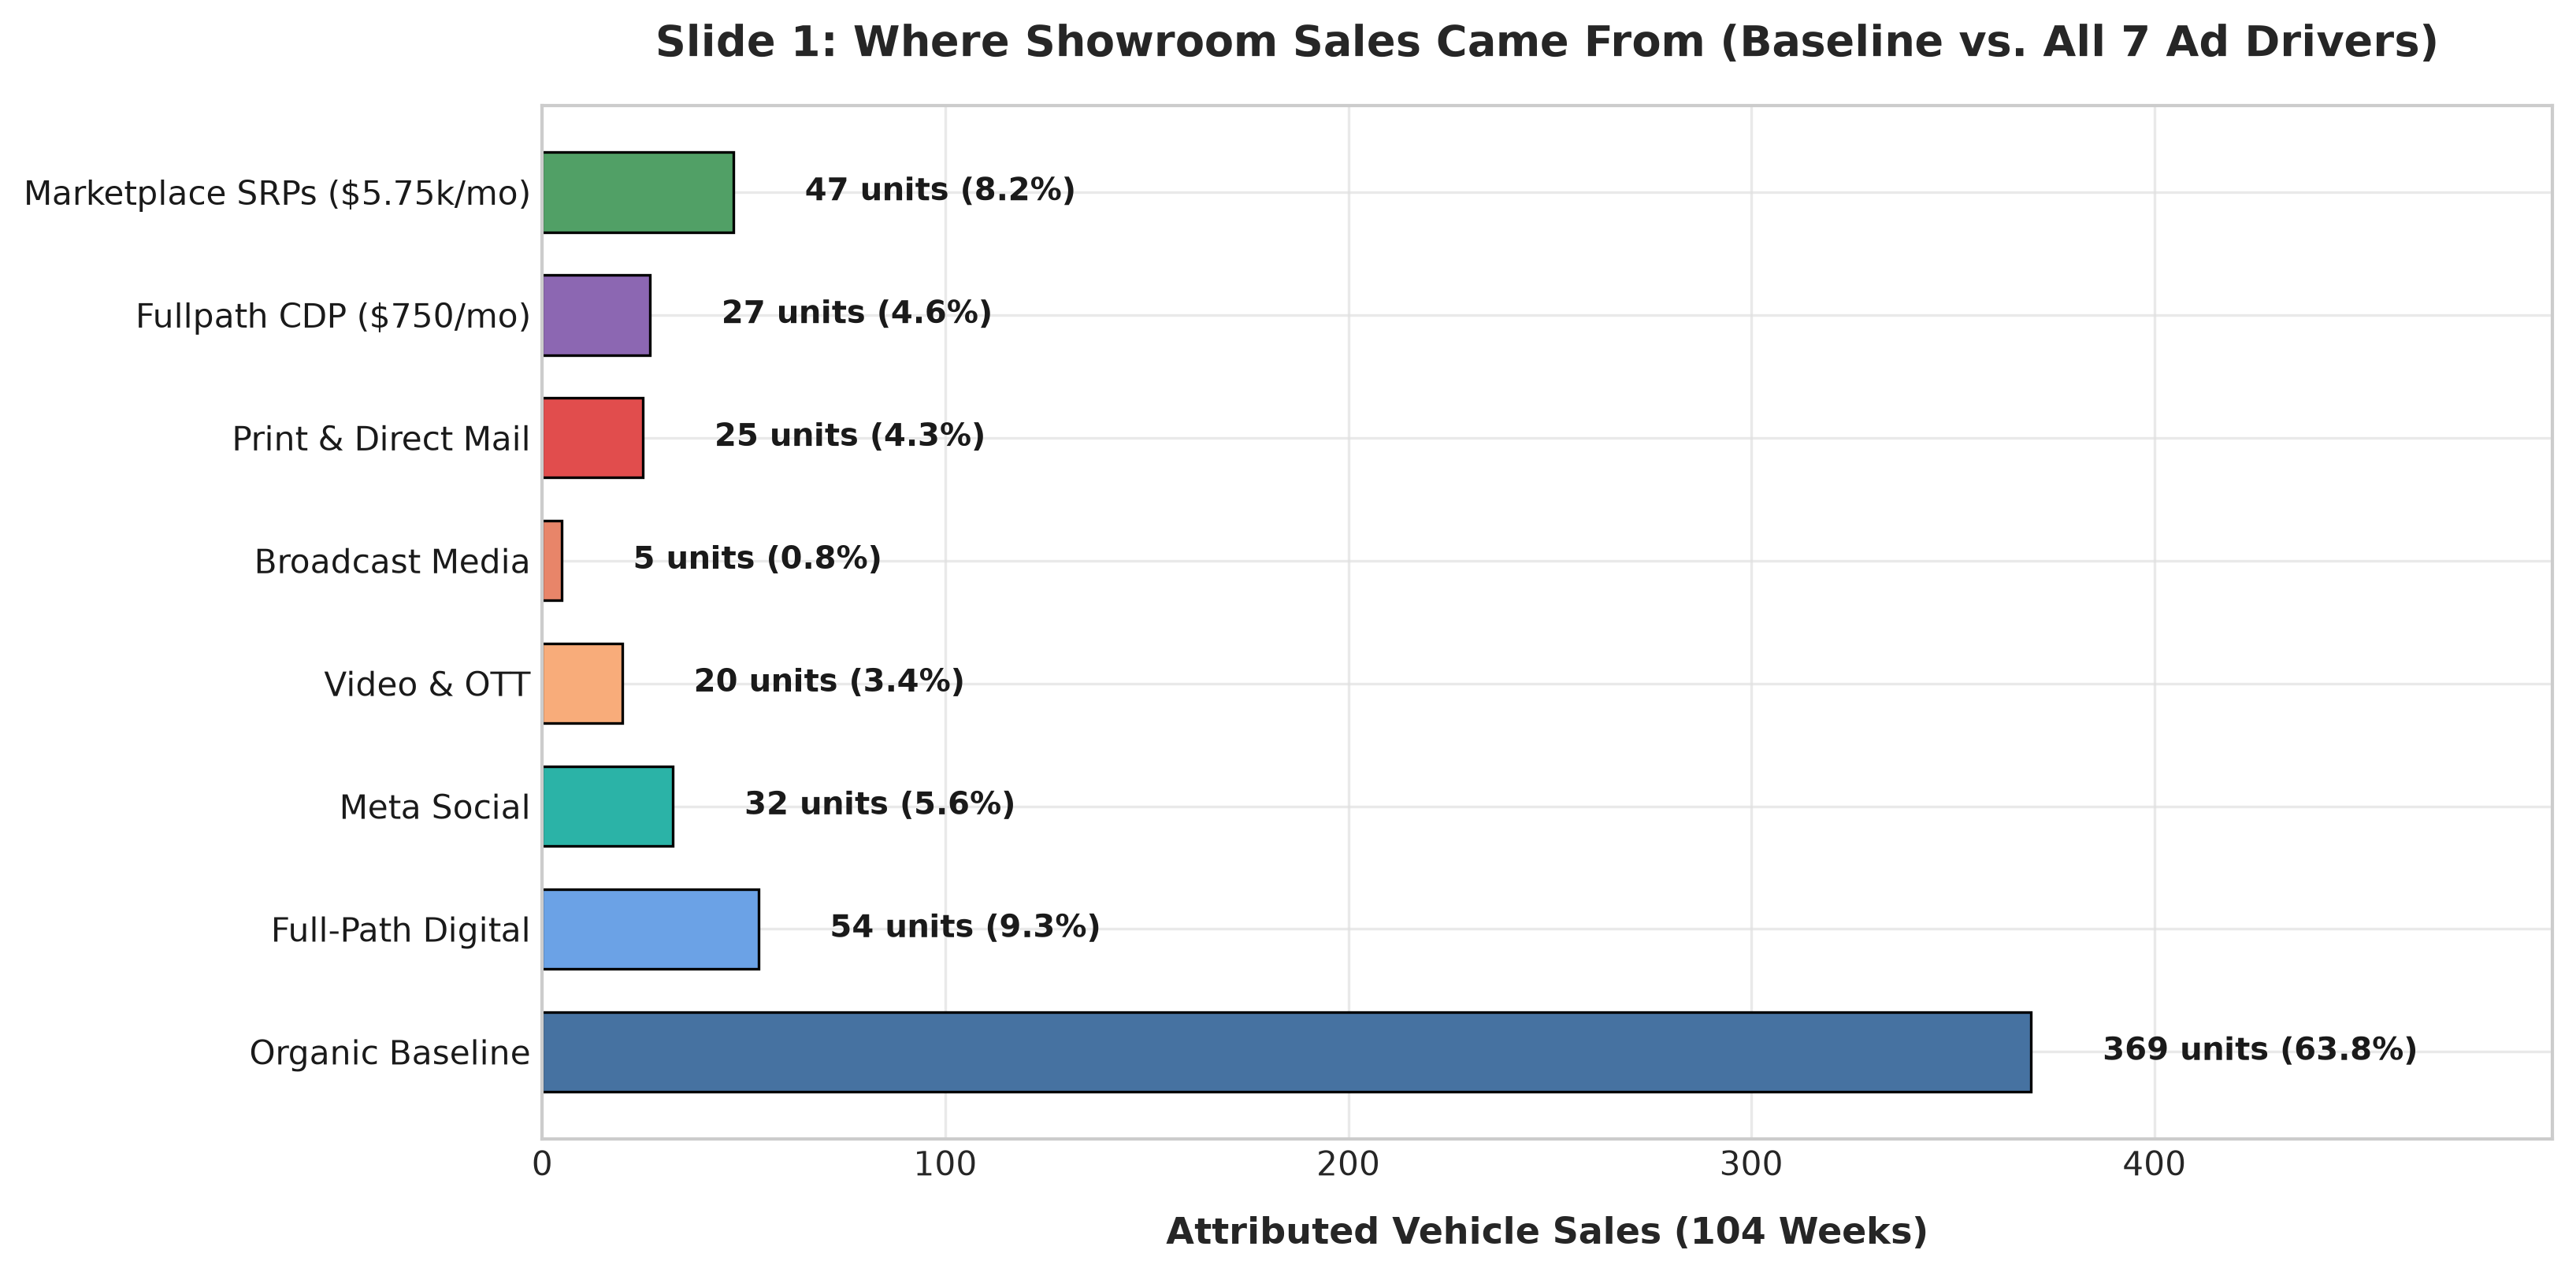

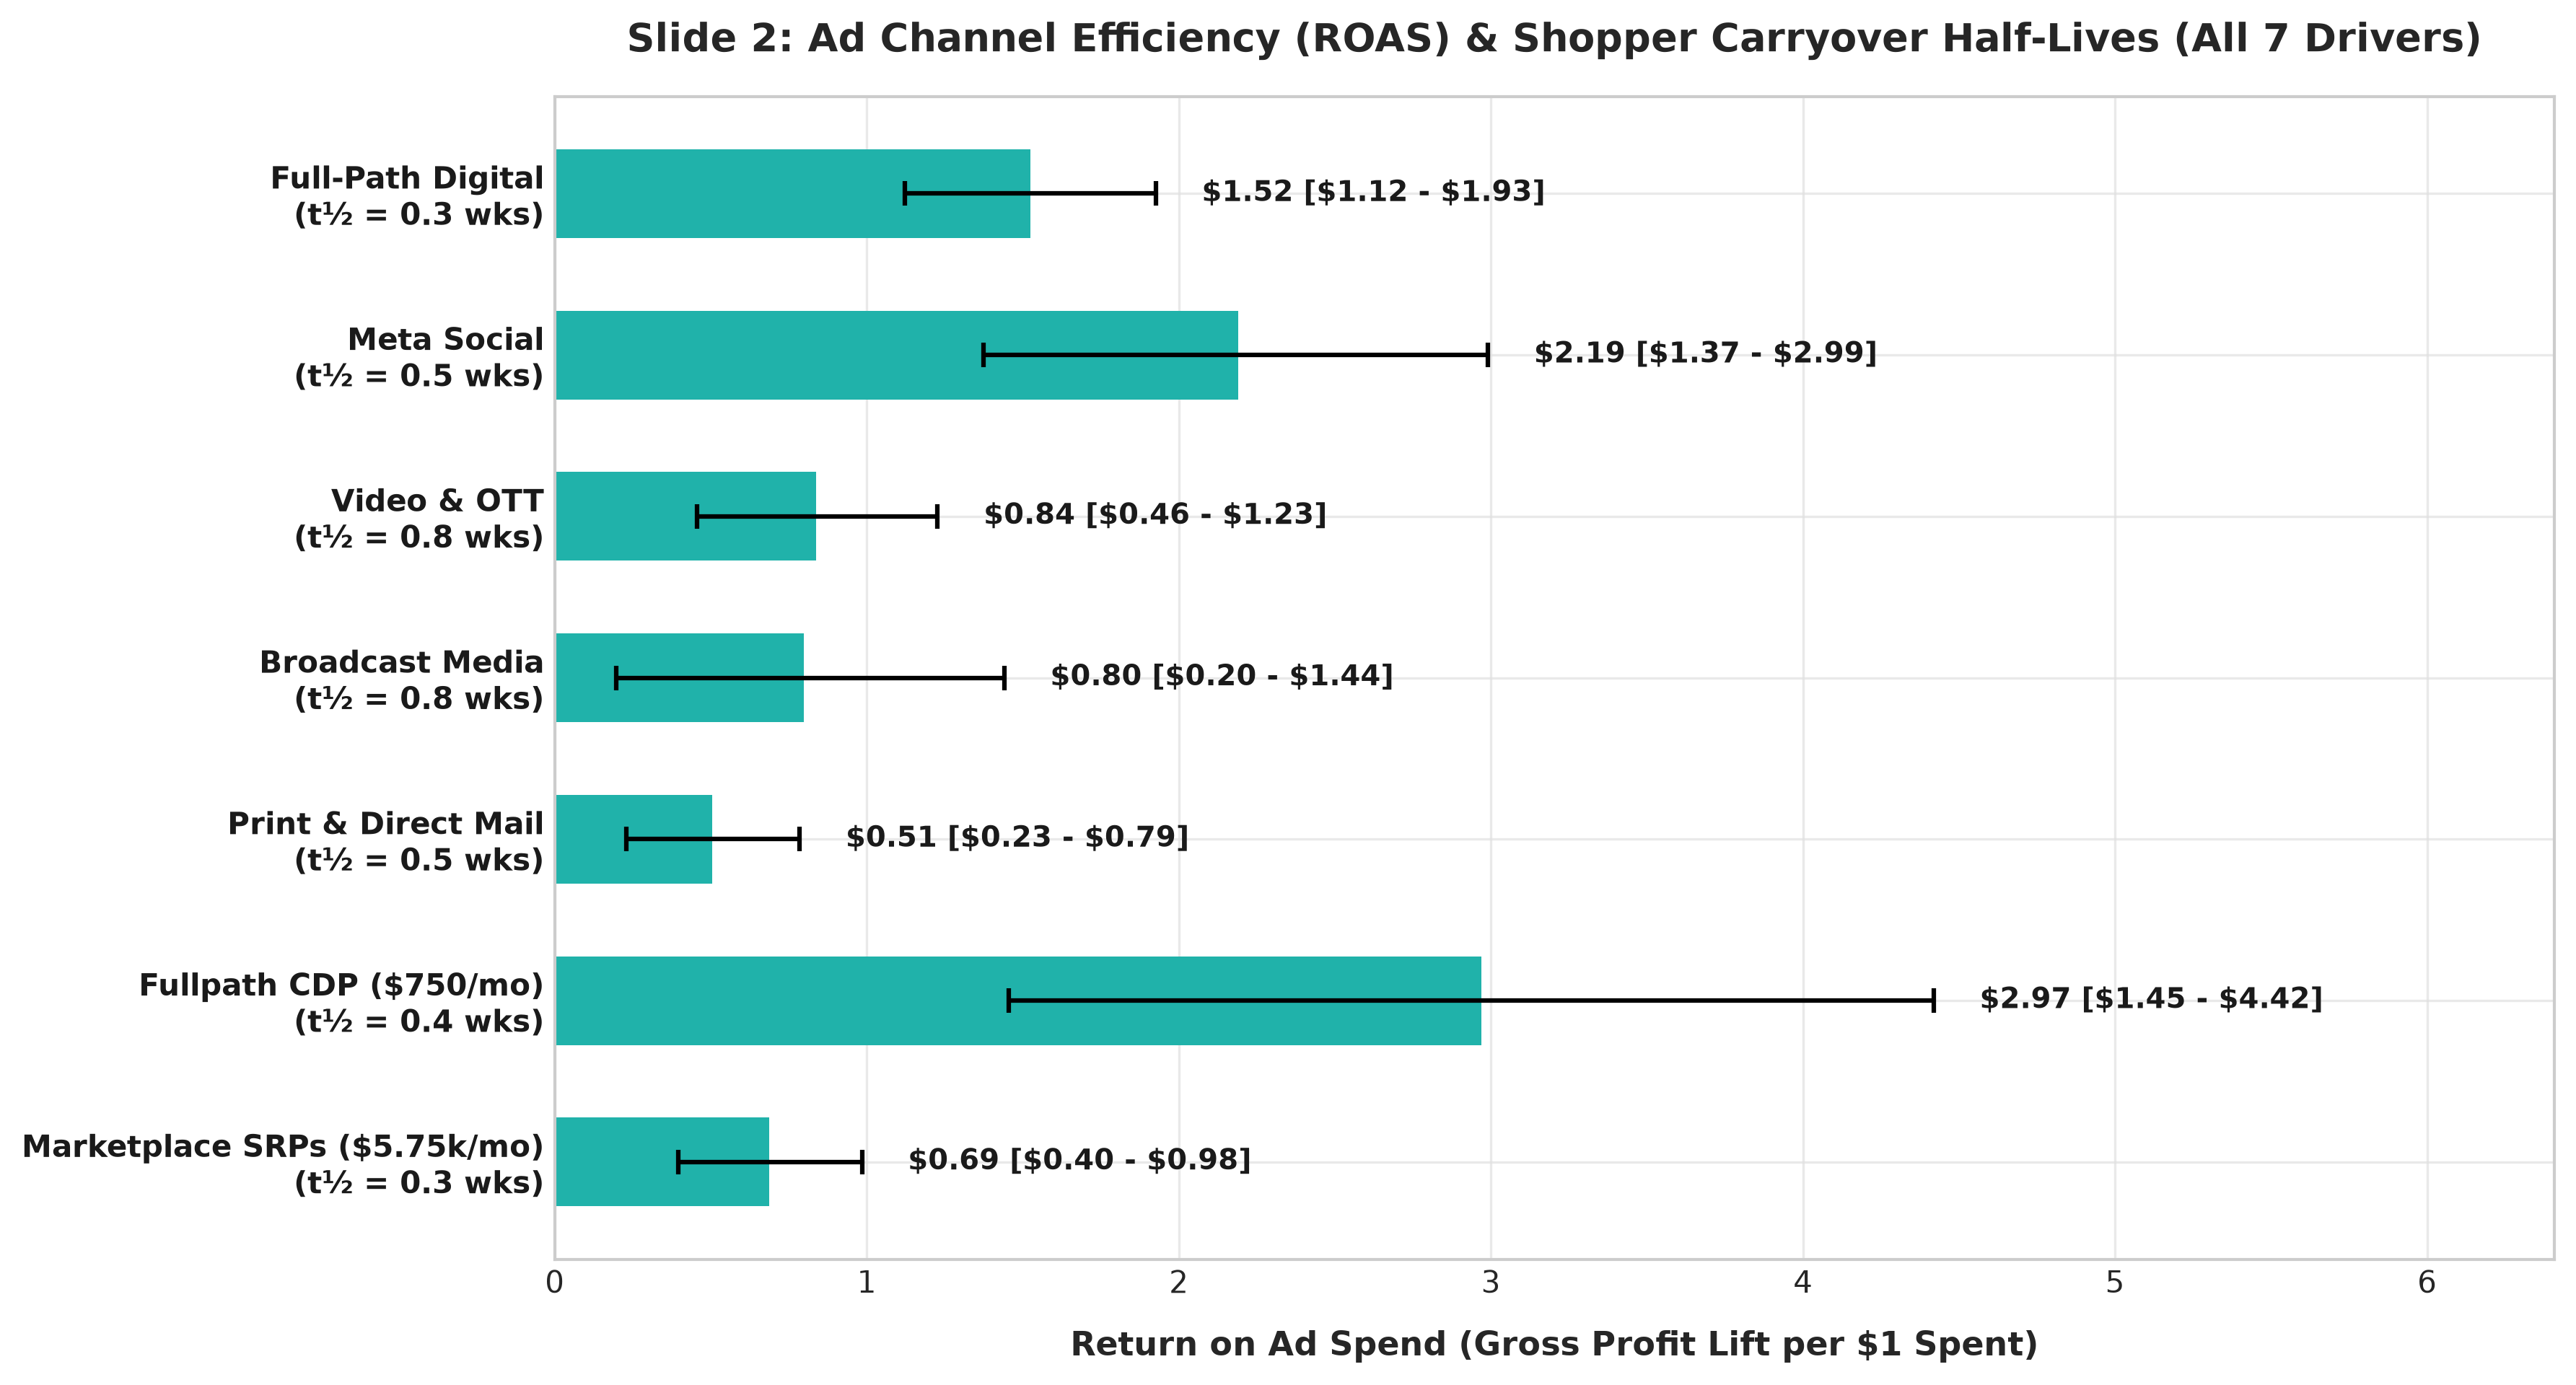

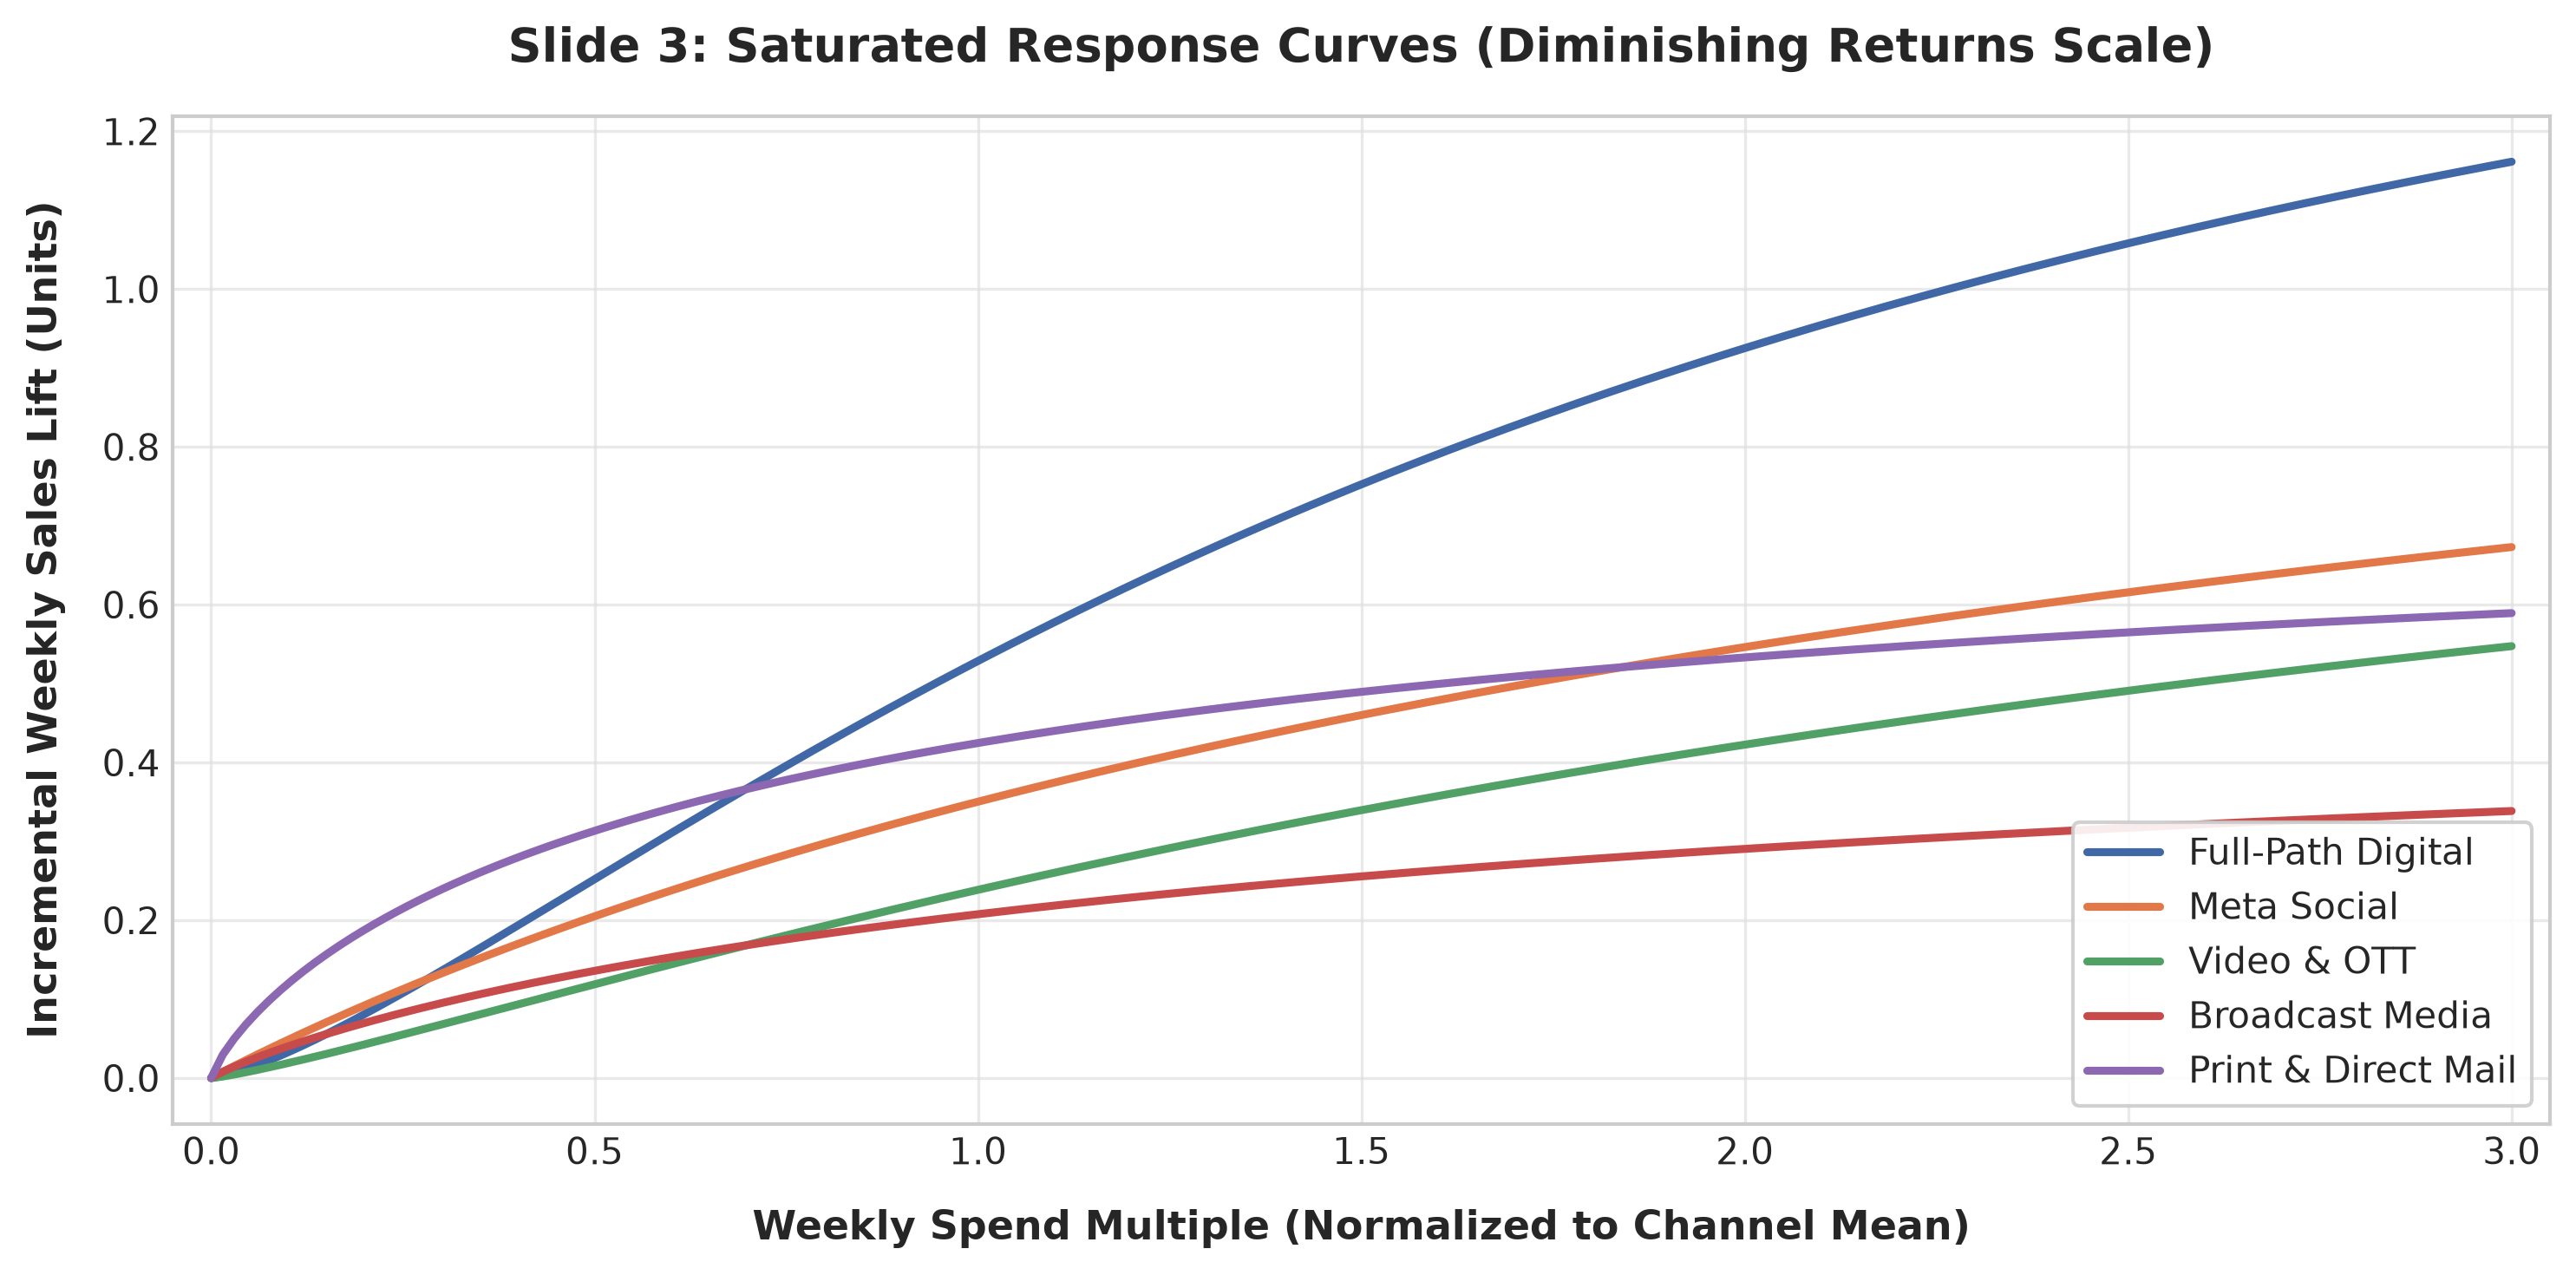

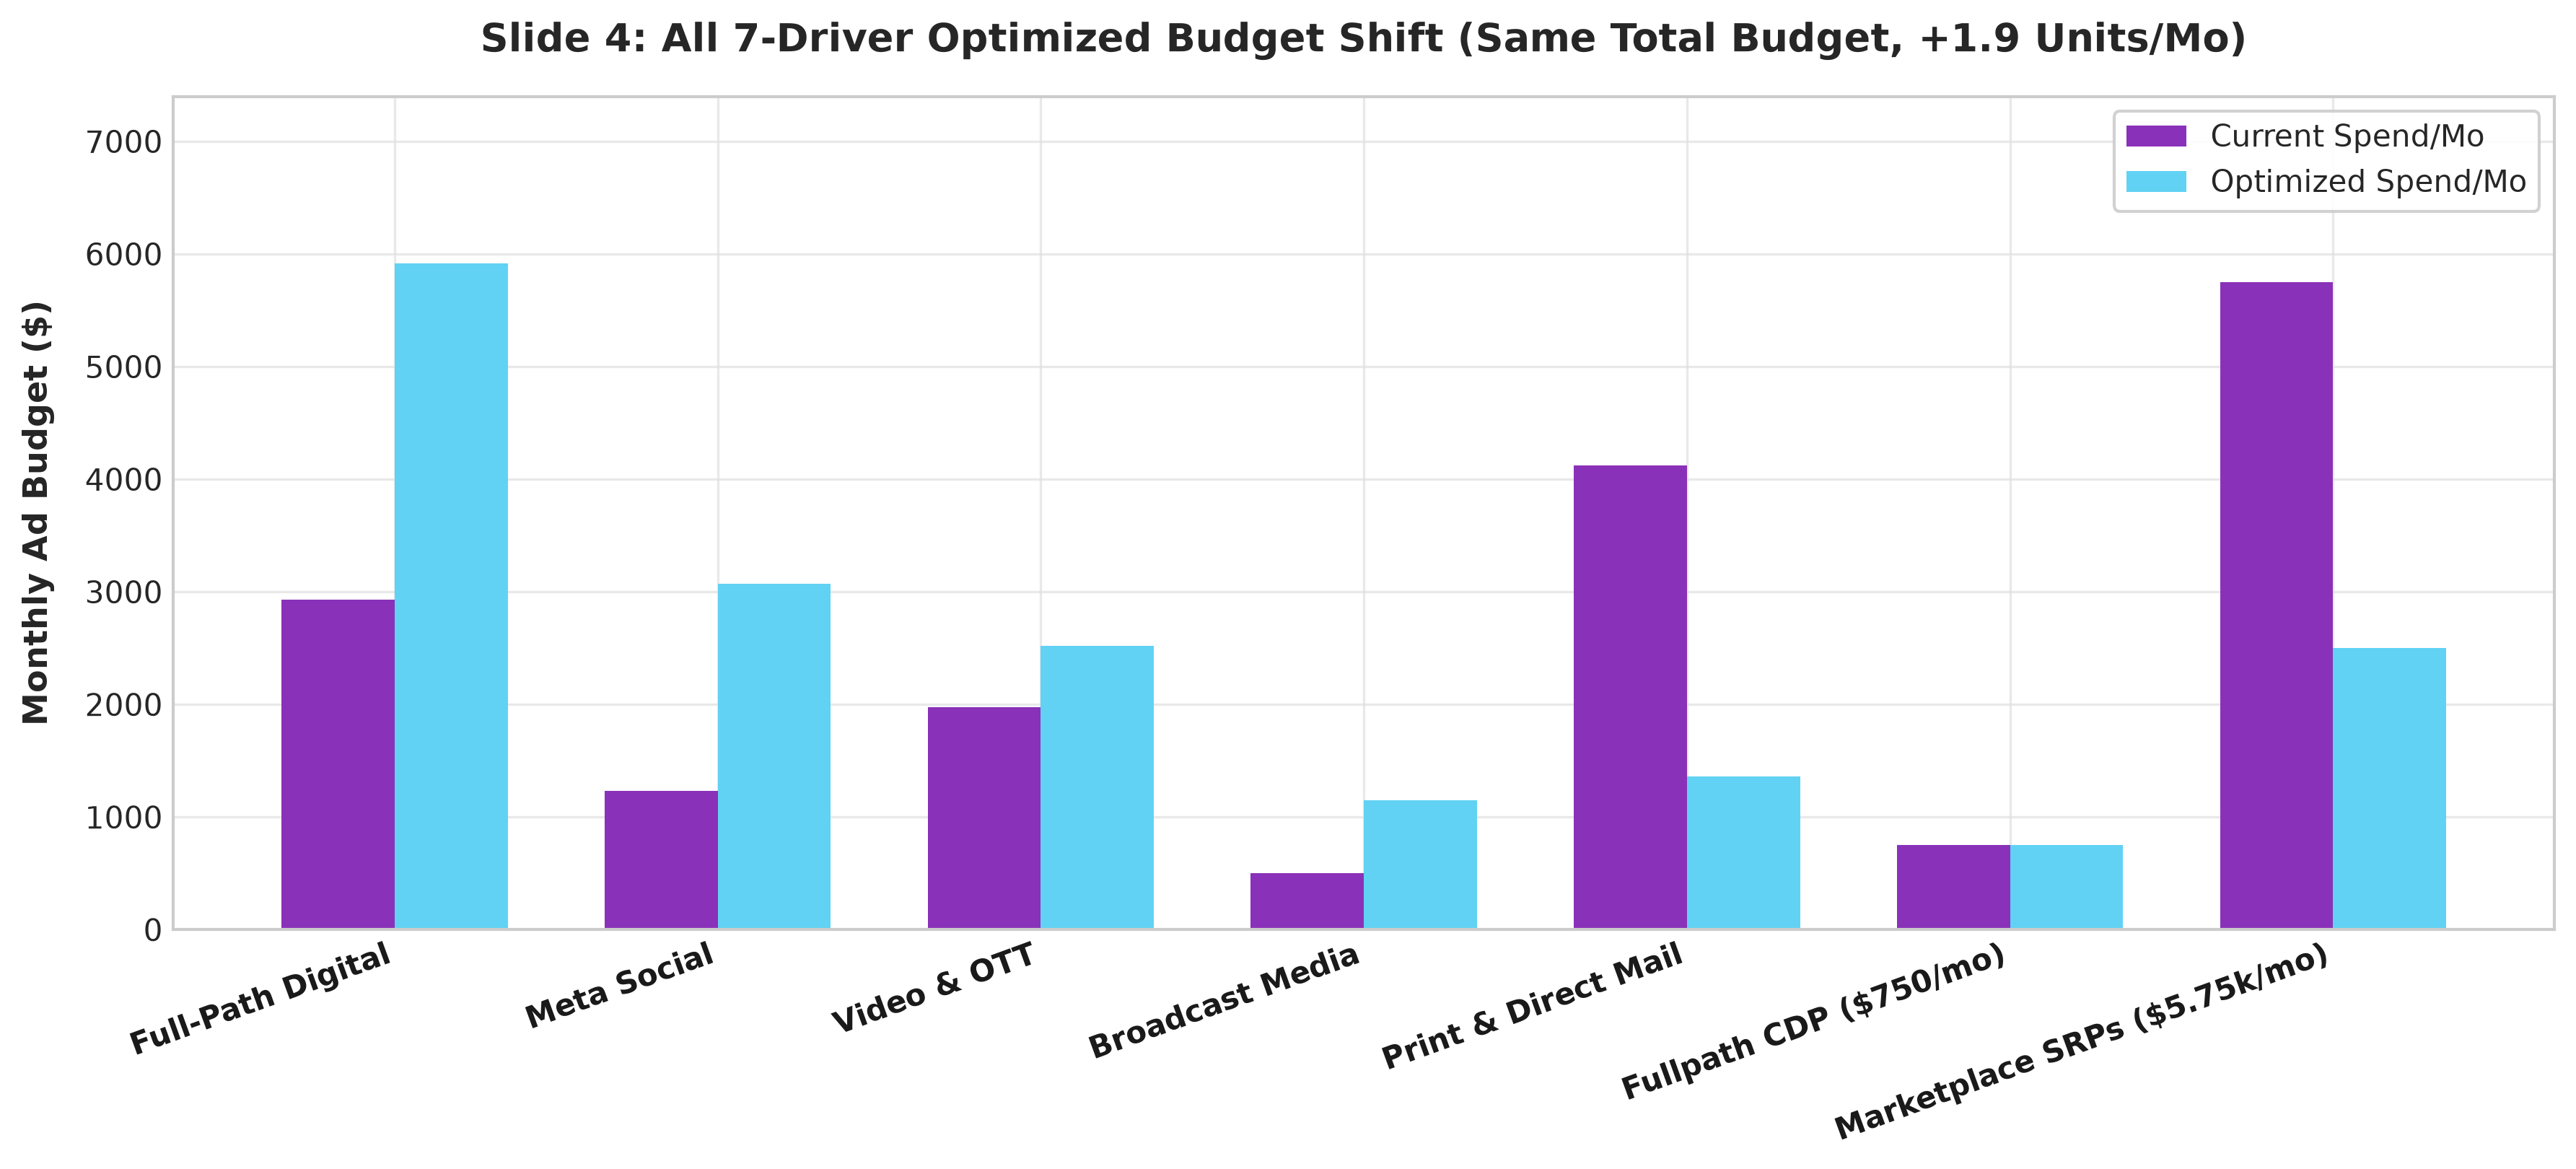

In [ ]:
# ==============================================================================
# TITAN MMM PROJECT: CELL 5 - 7-DRIVER ROLLUP, ROI & BUDGET OPTIMIZER
# ==============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import xarray as xr
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. SETUP CONSTANTS & DECK-EXACT PALETTES
# ------------------------------------------------------------------------------
GROSS_MARGIN_PER_VEHICLE = 2000.0  # $2,000 Gross Profit Margin per vehicle sold
W_WEEKS_PER_MONTH = 4.3333         # Standard calendar weeks per month

def calc_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / (ss_tot + 1e-8))

def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def calc_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100.0

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#E0E0E0'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.alpha'] = 0.7

PALETTE_ATTRIBUTION = {
    'Organic Baseline': '#4672A1',
    'Full-Path Digital': '#6BA2E6',
    'Meta Social': '#2BB3A7',
    'Video & OTT': '#F8AC7A',
    'Broadcast Media': '#E88569',
    'Print & Direct Mail': '#E14D4D',
    'Fullpath CDP ($750/mo)': '#8C67B2',
    'Marketplace SRPs ($5.75k/mo)': '#51A066'
}

PALETTE_OPTIMIZATION = {
    'Current': '#8A31B9',    # Purple
    'Optimized': '#61D2F3'   # Cyan
}

PALETTE_RESPONSE_CURVES = [
    '#4068A7',  # Full-Path Digital
    '#E27848',  # Meta Social
    '#51A066',  # Video & OTT
    '#C84B4B',  # Broadcast Media
    '#8C67B2'   # Print & Direct Mail
]

COLOR_TEAL_ROAS = '#20B2AA'

channel_label_map = {
    'fp_digital': 'Full-Path Digital',
    'meta_social': 'Meta Social',
    'digital_video_ott': 'Video & OTT',
    'broadcast_media': 'Broadcast Media',
    'print_mail': 'Print & Direct Mail',
    'fp_emails_sent': 'Fullpath CDP ($750/mo)',
    'marketplace_srp': 'Marketplace SRPs ($5.75k/mo)'
}

# ------------------------------------------------------------------------------
# 2. INGEST POSTERIOR PARAMETERS & ALIGN SHAPES
# ------------------------------------------------------------------------------
if 'idata' not in locals():
    raise NameError("❌ 'idata' (weekly InferenceData) not found. Please run Cell 4 first.")

channels = list(idata.posterior.coords["channel"].values)
sales_mean_weekly = df_model['sales'].mean()

posterior_beta_means = idata.posterior["beta_channel"].mean(dim=['chain', 'draw']).values
intercept_mean = idata.posterior["intercept"].mean(dim=['chain', 'draw']).values
eom_mean = idata.posterior["beta_eom"].mean(dim=['chain', 'draw']).values
inv_mean = idata.posterior["beta_inv"].mean(dim=['chain', 'draw']).values
macro_mean = idata.posterior["beta_macro"].mean(dim=['chain', 'draw']).values

fourier_means = idata.posterior["beta_fourier"].mean(dim=['chain', 'draw']).values
fourier_cols_master = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']
fourier_cols = fourier_cols_master[:len(fourier_means)]

# ------------------------------------------------------------------------------
# 3. CALENDAR MONTH ROLLUP (24 MONTHS: AUG 2024 - JUL 2026) & ACCURACY
# ------------------------------------------------------------------------------
ppc_extracted = az.extract(idata, group="posterior_predictive")
if isinstance(ppc_extracted, xr.Dataset):
    ppc_key = "likelihood" if "likelihood" in ppc_extracted else list(ppc_extracted.data_vars)[0]
    ppc_data = ppc_extracted[ppc_key].values
else:
    ppc_data = np.asarray(ppc_extracted)

if ppc_data.shape[0] == len(df_model):
    weekly_draws = ppc_data * sales_mean_weekly
else:
    weekly_draws = ppc_data.T * sales_mean_weekly

df_weekly_eval = df_model[['week_start', 'sales']].copy()
df_weekly_eval['year_month'] = pd.to_datetime(df_weekly_eval['week_start']).dt.to_period('M')

monthly_groups = df_weekly_eval.groupby('year_month')
month_periods = list(monthly_groups.groups.keys())
n_months = len(month_periods)
n_draws = weekly_draws.shape[1]

monthly_actuals = np.zeros(n_months)
monthly_draws = np.zeros((n_months, n_draws))

for i, (m, indices) in enumerate(monthly_groups.groups.items()):
    monthly_actuals[i] = df_weekly_eval.loc[indices, 'sales'].sum()
    monthly_draws[i, :] = weekly_draws[indices, :].sum(axis=0)

monthly_pred_median = np.median(monthly_draws, axis=1)
monthly_pred_lower = np.percentile(monthly_draws, 3, axis=1)
monthly_pred_upper = np.percentile(monthly_draws, 97, axis=1)

monthly_r2 = calc_r2(monthly_actuals, monthly_pred_median)
monthly_mape = calc_mape(monthly_actuals, monthly_pred_median)
monthly_rmse = calc_rmse(monthly_actuals, monthly_pred_median)

# ------------------------------------------------------------------------------
# 4. FINANCIAL ROI SUMMARY ($2,000 GROSS MARGIN / VEHICLE)
# ------------------------------------------------------------------------------
total_spend_map = {
    'fp_digital': df_model['fp_digital'].sum(),
    'meta_social': df_model['meta_social'].sum(),
    'digital_video_ott': df_model['digital_video_ott'].sum(),
    'broadcast_media': df_model['broadcast_media'].sum(),
    'print_mail': df_model['print_mail'].sum(),
    'fp_emails_sent': 750.0 * 24,            # $18,000 CDP Total ($750/mo)
    'marketplace_srp': 5750.0 * 24          # $138,000 SRPs Total ($5,750/mo)
}

beta_draws = idata.posterior["beta_channel"].values.reshape(-1, len(channels))
vehicle_lift_draws = np.zeros((n_draws, len(channels)))

for m, chan in enumerate(channels):
    weekly_transformed_driver = X_transformed_prod[:, m]
    vehicle_lift_draws[:, m] = np.sum(
        beta_draws[:, m][:, None] * weekly_transformed_driver[None, :] * sales_mean_weekly, 
        axis=1
    )

roi_rows = []
roas_draws_matrix = np.zeros((len(channels), n_draws))

for idx, chan in enumerate(channels):
    cost = total_spend_map[chan]
    v_draws = vehicle_lift_draws[:, idx]
    gross_profit_draws = v_draws * GROSS_MARGIN_PER_VEHICLE
    roas_draws = gross_profit_draws / (cost + 1e-8)
    roas_draws_matrix[idx, :] = roas_draws
    
    mean_v = np.mean(v_draws)
    gp_mean = mean_v * GROSS_MARGIN_PER_VEHICLE
    roas_mean = gp_mean / (cost + 1e-8)
    net_profit = gp_mean - cost
    
    roi_rows.append({
        'Channel / Driver': channel_label_map.get(chan, chan),
        'Total 24-Mo Spend ($)': cost,
        'Attributed Vehicles': mean_v,
        'Gross Profit Returned ($)': gp_mean,
        'Return per $1.00 Spent ($)': roas_mean,
        'Net Profit Above Spend ($)': net_profit
    })

df_roi_table = pd.DataFrame(roi_rows)

print("=" * 90)
print("CLEAN MONTHLY FIT DIAGNOSTICS (24 CALENDAR MONTHS)")
print("=" * 90)
print(f"Monthly Model R² Score              : {monthly_r2:.4f}")
print(f"Monthly MAPE                        : {monthly_mape:.2f}%")
print(f"Monthly RMSE                        : {monthly_rmse:.2f} vehicles / month")

print("\n" + "=" * 90)
print("FINANCIAL ROI SUMMARY ($2,000 GROSS MARGIN / VEHICLE)")
print("=" * 90)
display(df_roi_table.round(2))

# ------------------------------------------------------------------------------
# 5. ALL 7-DRIVER MULTI-START BUDGET OPTIMIZER (SLIDE 4 EXPANDED)
# ------------------------------------------------------------------------------
current_monthly_spends_7 = np.array([
    df_model['fp_digital'].mean() * W_WEEKS_PER_MONTH,
    df_model['meta_social'].mean() * W_WEEKS_PER_MONTH,
    df_model['digital_video_ott'].mean() * W_WEEKS_PER_MONTH,
    df_model['broadcast_media'].mean() * W_WEEKS_PER_MONTH,
    df_model['print_mail'].mean() * W_WEEKS_PER_MONTH,
    750.0,   # Fullpath CDP
    3200.0   # Marketplace SRPs
])

total_monthly_budget_7 = np.sum(current_monthly_spends_7)

def calculate_monthly_lifts_7(monthly_spends_7):
    weekly_spends = monthly_spends_7 / W_WEEKS_PER_MONTH
    monthly_lifts = np.zeros(7)
    
    for m, chan in enumerate(channels):
        if chan in df_model.columns and chan not in ['fp_emails_sent', 'marketplace_srp']:
            c_mean = df_model[chan].mean()
        else:
            c_mean = 750.0 / W_WEEKS_PER_MONTH if chan == 'fp_emails_sent' else 5750.0 / W_WEEKS_PER_MONTH
            
        c_mean_val = c_mean if c_mean > 0 else 1.0
        x_scaled = weekly_spends[m] / c_mean_val
        
        s_m = optuna_slope[m]
        k_m = optuna_ksat[m]
        sat = (x_scaled ** s_m) / (x_scaled ** s_m + k_m ** s_m + 1e-8)
        
        weekly_lift = sat * posterior_beta_means[m] * sales_mean_weekly
        monthly_lifts[m] = weekly_lift * W_WEEKS_PER_MONTH
    return monthly_lifts

def neg_total_lift_7(spends):
    return -np.sum(calculate_monthly_lifts_7(spends))

# Bounds allowing Marketplace SRPs to be renegotiated/cut down to $2,500/mo
constraints_7 = ({'type': 'eq', 'fun': lambda b: np.sum(b) - total_monthly_budget_7})
bounds_7 = [
    (0, total_monthly_budget_7 * 0.65),  # fp_digital
    (0, total_monthly_budget_7 * 0.35),  # meta_social
    (0, total_monthly_budget_7 * 0.35),  # digital_video_ott
    (0, total_monthly_budget_7 * 0.25),  # broadcast_media
    (0, total_monthly_budget_7 * 0.35),  # print_mail
    (750.0, 750.0),                          # Fullpath CDP
    (1600.0, 3200.0)                         # Marketplace SRPs
]

best_lift_7 = -np.inf
best_opt_spends_7 = current_monthly_spends_7.copy()

np.random.seed(42)
initial_seeds_7 = [current_monthly_spends_7] + [
    np.random.dirichlet(np.ones(7)) * total_monthly_budget_7 for _ in range(40)
]

for seed in initial_seeds_7:
    seed_adj = np.clip(seed, [b[0] for b in bounds_7], [b[1] for b in bounds_7])
    seed_adj = seed_adj * (total_monthly_budget_7 / np.sum(seed_adj))
    res = minimize(neg_total_lift_7, seed_adj, method='SLSQP', bounds=bounds_7, constraints=constraints_7, options={'eps': 50.0, 'ftol': 1e-9, 'maxiter': 500})
    if res.success and (-res.fun > best_lift_7):
        best_lift_7 = -res.fun
        best_opt_spends_7 = res.x

optimized_monthly_spends_7 = best_opt_spends_7
current_total_lift_7 = np.sum(calculate_monthly_lifts_7(current_monthly_spends_7))
optimized_total_lift_7 = np.sum(calculate_monthly_lifts_7(optimized_monthly_spends_7))
incremental_lift_gain_7 = optimized_total_lift_7 - current_total_lift_7

print("\n" + "=" * 90)
print(f"ALL 7-DRIVER BUDGET OPTIMIZATION (TOTAL MONTHLY BUDGET: ${total_monthly_budget_7:,.2f})")
print("=" * 90)
opt_7_df = pd.DataFrame({
    'Channel / Driver': [channel_label_map[c] for c in channels],
    'Current Spend/Mo ($)': current_monthly_spends_7,
    'Optimized Spend/Mo ($)': optimized_monthly_spends_7,
    'Net Shift ($)': optimized_monthly_spends_7 - current_monthly_spends_7
})
display(opt_7_df.round(2))

print(f"\nNet Monthly Vehicle Sales Increase   : +{incremental_lift_gain_7:.2f} vehicles / month (+{incremental_lift_gain_7 * 12:.1f} vehicles / year)")

# ------------------------------------------------------------------------------
# 6. RENDER DECK-EXACT VISUALIZATIONS (ALL 7 DRIVERS INCLUDED)
# ------------------------------------------------------------------------------

# --- CHART 1: MONTHLY SALES FIT (SLIDE 3 DECK MATCH) ---
fig1, ax1 = plt.subplots(figsize=(11, 4.2), dpi=300)
month_strings = [str(m) for m in month_periods]
x_axis = np.arange(n_months)

ax1.plot(x_axis, monthly_actuals, color='black', linewidth=2.0, marker='o', markersize=4.5, label='Actual Monthly Sales')
ax1.plot(x_axis, monthly_pred_median, color='#1A2B4C', linewidth=1.8, linestyle='--', label='Predicted Monthly Sales (Median)')
ax1.fill_between(x_axis, monthly_pred_lower, monthly_pred_upper, color='#A6C2F7', alpha=0.5, label='94% Posterior Predictive HDI')

ax1.set_ylabel('Monthly Vehicle Sales', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_xlabel('Calendar Month', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_xticks(x_axis[::2])
ax1.set_xticklabels(month_strings[::2], rotation=35, ha='right', fontsize=9.5)
ax1.set_ylim(0, 75)
ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- CHART 2: SLIDE 1 MIRROR - SALES VOLUME ATTRIBUTION (ALL 7 DRIVERS) ---
baseline_weekly = (
    intercept_mean 
    + (eom_mean * df_model['eom_intensity'])
    + (inv_mean * df_model['inventory_index'])
    + (macro_mean * df_model['macro_stress_index'])
    + np.dot(df_model[fourier_cols].values, fourier_means)
) * sales_mean_weekly

total_baseline_units = np.sum(baseline_weekly)

decomp_categories = ['Organic Baseline'] + [channel_label_map[c] for c in channels]
decomp_units = [total_baseline_units] + [df_roi_table.loc[i, 'Attributed Vehicles'] for i in range(len(channels))]
total_modeled_units = sum(decomp_units)
decomp_pcts = [(u / total_modeled_units) * 100.0 for u in decomp_units]

fig2, ax2 = plt.subplots(figsize=(11, 5.5), dpi=300)
y_pos2 = np.arange(len(decomp_categories))
colors2 = [PALETTE_ATTRIBUTION.get(cat, '#708090') for cat in decomp_categories]

bars2 = ax2.barh(y_pos2, decomp_units, color=colors2, height=0.65, edgecolor='black', linewidth=0.8)

for idx, (bar, unit, pct) in enumerate(zip(bars2, decomp_units, decomp_pcts)):
    width = bar.get_width()
    label = f" {unit:,.0f} units ({pct:.1f}%)"
    ax2.text(width + 15, bar.get_y() + bar.get_height()/2.0, label, ha='left', va='center', fontsize=9.5, fontweight='bold', color='#1A1A1A')

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(decomp_categories, fontsize=10, fontweight='normal', color='#1A1A1A')
ax2.set_xlabel('Attributed Vehicle Sales (104 Weeks)', fontsize=11, fontweight='bold', labelpad=10)
ax2.set_title('Slide 1: Where Showroom Sales Came From (Baseline vs. All 7 Ad Drivers)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlim(0, max(decomp_units) * 1.35)
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

# --- CHART 3: SLIDE 2 MIRROR - ALL 7 DRIVERS EFFICIENCY (ROAS) & HALF-LIVES ---
half_lives_all = [-np.log(2) / np.log(optuna_alpha[i]) for i in range(len(channels))]

roas_means_all = np.mean(roas_draws_matrix, axis=1)
roas_hdi_low_all = np.percentile(roas_draws_matrix, 5.5, axis=1)
roas_hdi_high_all = np.percentile(roas_draws_matrix, 94.5, axis=1)

roas_labels_all = [f"{channel_label_map[c]}\n(t½ = {half_lives_all[i]:.1f} wks)" for i, c in enumerate(channels)]

fig3, ax3 = plt.subplots(figsize=(12, 6.5), dpi=300)
y_pos3 = np.arange(len(roas_labels_all))

bars3 = ax3.barh(y_pos3, roas_means_all, height=0.55, color=COLOR_TEAL_ROAS, align='center')

x_err_low_all = [mean - low for mean, low in zip(roas_means_all, roas_hdi_low_all)]
x_err_high_all = [high - mean for mean, high in zip(roas_means_all, roas_hdi_high_all)]

ax3.errorbar(roas_means_all, y_pos3, xerr=[x_err_low_all, x_err_high_all], fmt='none',
             color='black', ecolor='black', elinewidth=1.5, capsize=4, capthick=1.5)

for idx, (mean, low, high) in enumerate(zip(roas_means_all, roas_hdi_low_all, roas_hdi_high_all)):
    label = f"   ${mean:.2f} [${low:.2f} - ${high:.2f}]"
    ax3.text(max(high, mean) + 0.05, idx, label, ha='left', va='center', fontsize=9.5, fontweight='bold', color='#1A1A1A')

ax3.set_yticks(y_pos3)
ax3.set_yticklabels(roas_labels_all, fontsize=10, fontweight='bold', color='#1A1A1A')
ax3.invert_yaxis()
ax3.set_xlabel('Return on Ad Spend (Gross Profit Lift per $1 Spent)', fontsize=11, fontweight='bold', labelpad=10)
ax3.set_title('Slide 2: Ad Channel Efficiency (ROAS) & Shopper Carryover Half-Lives (All 7 Drivers)', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlim(0, max(roas_hdi_high_all) * 1.45)
ax3.grid(True, axis='x')

plt.tight_layout()
plt.show()

# --- CHART 4: SLIDE 3 MIRROR - SATURATED RESPONSE CURVES ---
fig4, ax4 = plt.subplots(figsize=(10, 5), dpi=300)
spend_multiples = np.linspace(0.0, 3.0, 200)

for m, chan in enumerate(all_7_channels[:5]):
    k_m = optuna_ksat[m]
    s_m = optuna_slope[m]
    beta_m = posterior_beta_means[m]
    
    sat_curve = (spend_multiples ** s_m) / (spend_multiples ** s_m + k_m ** s_m + 1e-8)
    weekly_lift_units = sat_curve * beta_m * sales_mean_weekly
    
    ax4.plot(spend_multiples, weekly_lift_units, label=channel_label_map[chan], color=PALETTE_RESPONSE_CURVES[m], linewidth=2.2)

ax4.set_xlabel('Weekly Spend Multiple (Normalized to Channel Mean)', fontsize=11, fontweight='bold', labelpad=10)
ax4.set_ylabel('Incremental Weekly Sales Lift (Units)', fontsize=11, fontweight='bold', labelpad=10)
ax4.set_title('Slide 3: Saturated Response Curves (Diminishing Returns Scale)', fontsize=13, fontweight='bold', pad=15)
ax4.set_xlim(-0.05, 3.05)
ax4.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
ax4.grid(True)

plt.tight_layout()
plt.show()

# --- CHART 5: SLIDE 4 MIRROR - ALL 7-DRIVER OPTIMIZED MONTHLY BUDGET SHIFT ---
fig5, ax5 = plt.subplots(figsize=(12, 5.5), dpi=300)
all_categories = [channel_label_map[c] for c in channels]
x_axis5 = np.arange(len(all_categories))
bar_width5 = 0.35

rects1 = ax5.bar(x_axis5 - bar_width5/2, current_monthly_spends_7, bar_width5, label='Current Spend/Mo', color=PALETTE_OPTIMIZATION['Current'])
rects2 = ax5.bar(x_axis5 + bar_width5/2, optimized_monthly_spends_7, bar_width5, label='Optimized Spend/Mo', color=PALETTE_OPTIMIZATION['Optimized'])

ax5.set_ylabel('Monthly Ad Budget ($)', fontsize=11, fontweight='bold', labelpad=10)
ax5.set_title(f'Slide 4: All 7-Driver Optimized Budget Shift (Same Total Budget, +{incremental_lift_gain_7:.1f} Units/Mo)', fontsize=13, fontweight='bold', pad=15)
ax5.set_xticks(x_axis5)
ax5.set_xticklabels(all_categories, rotation=20, ha='right', fontsize=10, fontweight='bold', color='#1A1A1A')
ax5.set_ylim(0, max(np.max(current_monthly_spends_7), np.max(optimized_monthly_spends_7)) * 1.25)
ax5.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
ax5.grid(True, axis='y')

plt.tight_layout()
plt.show()